In [1]:
pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import math
import random

random.seed(42)

def randn():
    u = random.random() or 1e-10
    v = random.random() or 1e-10
    return math.sqrt(-2 * math.log(u)) * math.cos(2 * math.pi * v)

def dot(a, b):
    return sum(x * y for x, y in zip(a, b))

def mean(lst):
    return sum(lst) / len(lst)

print('✅')

✅


In [3]:
N = 100
noise = 0.4

X = [[random.uniform(-3, 3)] for _ in range(N)]
Y = [2.0 * x[0] + 1.0 + randn() * noise for x in X]

print(f'Dataset: {N} sampel')
print(f'X[0..4]: {[round(x[0],3) for x in X[:5]]}')
print(f'Y[0..4]: {[round(y,3) for y in Y[:5]]}')

Dataset: 100 sampel
X[0..4]: [0.837, -2.85, -1.35, -1.661, 1.419]
Y[0..4]: [2.454, -5.041, -2.111, -3.09, 4.32]


In [4]:
w = randn() * 0.1
b = randn() * 0.1
print(f'Bobot awal  →  w = {w:.4f},  b = {b:.4f}')

Bobot awal  →  w = -0.0431,  b = -0.0522


In [5]:
def forward(x, w, b):
    return w * x[0] + b
sample = X[0]
y_hat = forward(sample, w, b)
print(f'x = {sample[0]:.4f}')
print(f'y_hat = {y_hat:.4f}  (target: {Y[0]:.4f})')

x = 0.8366
y_hat = -0.0883  (target: 2.4544)


In [6]:
def mse_loss(X, Y, w, b):
    total = 0.0
    for x, y in zip(X, Y):
        y_hat = forward(x, w, b)
        total += (y_hat - y) ** 2
    return total / len(X)

loss_awal = mse_loss(X, Y, w, b)
print(f'Loss awal: {loss_awal:.4f}')

Loss awal: 14.1362


In [7]:
def compute_gradients(batch_X, batch_Y, w, b):
    dw = 0.0
    db = 0.0
    n = len(batch_X)
    for x, y in zip(batch_X, batch_Y):
        y_hat = forward(x, w, b)
        error = y_hat - y          
        dw += error * x[0]         
        db += error               
    return dw / n, db / n

dw, db = compute_gradients(X, Y, w, b)
print(f'Gradien  →  dw = {dw:.4f},  db = {db:.4f}')

Gradien  →  dw = -6.3337,  db = -0.8009


In [8]:
def sgd_update(w, b, dw, db, lr):
    w_new = w - lr * dw
    b_new = b - lr * db
    return w_new, b_new

lr = 0.01
w, b = sgd_update(w, b, dw, db, lr)
print(f'Setelah 1 step  →  w = {w:.4f},  b = {b:.4f}')
print(f'Loss baru: {mse_loss(X, Y, w, b):.4f}')

Setelah 1 step  →  w = 0.0202,  b = -0.0442
Loss baru: 13.3335


In [9]:
w = randn() * 0.1
b = randn() * 0.1

# Hyperparameter
lr         = 0.01
epochs     = 200
batch_size = 1    

loss_history = []

for epoch in range(1, epochs + 1):

    indices = list(range(len(X)))
    random.shuffle(indices)

    for start in range(0, len(indices), batch_size):
        batch_idx = indices[start : start + batch_size]
        bX = [X[i] for i in batch_idx]
        bY = [Y[i] for i in batch_idx]

        dw, db = compute_gradients(bX, bY, w, b)
        w, b   = sgd_update(w, b, dw, db, lr)

    loss = mse_loss(X, Y, w, b)
    loss_history.append(loss)

    if epoch % 20 == 0 or epoch == 1:
        print(f'Epoch {epoch:4d}  |  loss = {loss:.5f}  |  w = {w:.4f}  b = {b:.4f}')

print(f'\n✅ Training selesai!')
print(f'   Target  : w ≈ 2.0,  b ≈ 1.0')
print(f'   Hasil   : w = {w:.4f},  b = {b:.4f}')

Epoch    1  |  loss = 0.29244  |  w = 1.9272  b = 0.6707
Epoch   20  |  loss = 0.15790  |  w = 2.0190  b = 0.9868
Epoch   40  |  loss = 0.15885  |  w = 2.0493  b = 0.9830
Epoch   60  |  loss = 0.15730  |  w = 2.0313  b = 0.9971
Epoch   80  |  loss = 0.15753  |  w = 2.0214  b = 0.9998
Epoch  100  |  loss = 0.15736  |  w = 2.0272  b = 0.9951
Epoch  120  |  loss = 0.16041  |  w = 1.9988  b = 0.9967
Epoch  140  |  loss = 0.15763  |  w = 2.0409  b = 1.0102
Epoch  160  |  loss = 0.15771  |  w = 2.0422  b = 0.9994
Epoch  180  |  loss = 0.15741  |  w = 2.0365  b = 0.9977
Epoch  200  |  loss = 0.15904  |  w = 2.0533  b = 1.0185

✅ Training selesai!
   Target  : w ≈ 2.0,  b ≈ 1.0
   Hasil   : w = 2.0533,  b = 1.0185


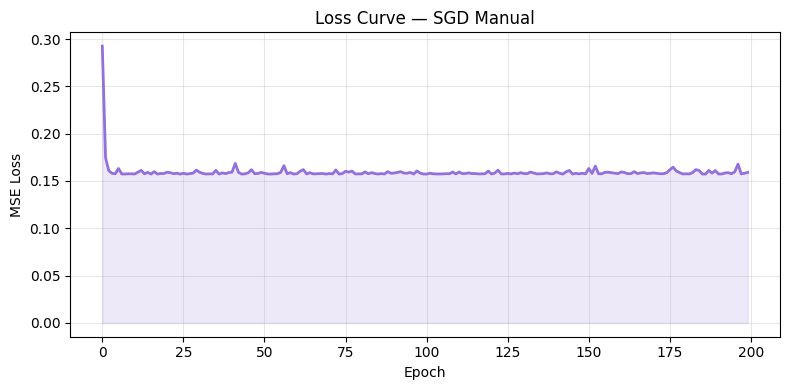

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(loss_history, color='mediumpurple', linewidth=2)
plt.fill_between(range(len(loss_history)), loss_history, alpha=0.15, color='mediumpurple')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Loss Curve — SGD Manual')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

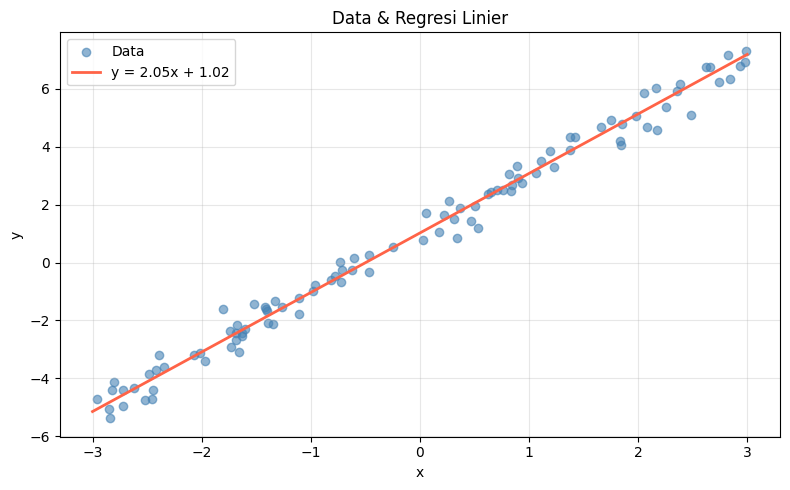

In [11]:
import matplotlib.pyplot as plt

x_vals = [i / 10 - 3 for i in range(61)]         
y_pred = [w * xv + b for xv in x_vals]

plt.figure(figsize=(8, 5))
plt.scatter([x[0] for x in X], Y, alpha=0.6, color='steelblue', label='Data')
plt.plot(x_vals, y_pred, color='tomato', linewidth=2, label=f'y = {w:.2f}x + {b:.2f}')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Data & Regresi Linier')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [12]:
def make_kfold(n_samples, k, shuffle=True, seed=50):
    indices = list(range(n_samples))
    if shuffle:
        rng = random.Random(seed)
        rng.shuffle(indices)

    fold_size = n_samples // k
    folds = []

    for i in range(k):
        start = i * fold_size
        end   = start + fold_size if i < k - 1 else n_samples
        val_idx   = indices[start:end]
        train_idx = indices[:start] + indices[end:]
        folds.append((train_idx, val_idx))

    return folds

K = 10
folds = make_kfold(len(X), k=K)

print(f'K-Fold  ->  K = {K},  total data = {len(X)}')
for i, (tr, vl) in enumerate(folds):
    print(f'  Fold {i+1}:  train={len(tr):3d} sampel  |  val={len(vl):3d} sampel')

K-Fold  ->  K = 10,  total data = 100
  Fold 1:  train= 90 sampel  |  val= 10 sampel
  Fold 2:  train= 90 sampel  |  val= 10 sampel
  Fold 3:  train= 90 sampel  |  val= 10 sampel
  Fold 4:  train= 90 sampel  |  val= 10 sampel
  Fold 5:  train= 90 sampel  |  val= 10 sampel
  Fold 6:  train= 90 sampel  |  val= 10 sampel
  Fold 7:  train= 90 sampel  |  val= 10 sampel
  Fold 8:  train= 90 sampel  |  val= 10 sampel
  Fold 9:  train= 90 sampel  |  val= 10 sampel
  Fold 10:  train= 90 sampel  |  val= 10 sampel


In [13]:
def train_fold(X, Y, train_idx, val_idx,
               lr=0.01, epochs=200, batch_size=1):
    X_tr = [X[i] for i in train_idx]
    Y_tr = [Y[i] for i in train_idx]
    X_vl = [X[i] for i in val_idx]
    Y_vl = [Y[i] for i in val_idx]
    fw = randn() * 0.5
    fb = randn() * 0.5

    train_losses = []

    for epoch in range(1, epochs + 1):
        idx = list(range(len(X_tr)))
        random.shuffle(idx)

        for start in range(0, len(idx), batch_size):
            batch  = idx[start : start + batch_size]
            bX     = [X_tr[i] for i in batch]
            bY     = [Y_tr[i] for i in batch]
            dw, db = compute_gradients(bX, bY, fw, fb)
            fw, fb = sgd_update(fw, fb, dw, db, lr)

        train_losses.append(mse_loss(X_tr, Y_tr, fw, fb))

    val_loss = mse_loss(X_vl, Y_vl, fw, fb)
    return fw, fb, train_losses, val_loss

print('train_fold')

train_fold


In [14]:
K         = 10
lr_cv     = 0.1
epochs_cv = 200
bs_cv     = 1

folds      = make_kfold(len(X), k=K, shuffle=True, seed=42)
cv_results = []

sep = '-' * 58
print(sep)
print(f'  K-Fold CV  |  K={K}  lr={lr_cv}  epochs={epochs_cv}  bs={bs_cv}')
print(sep)
print(f'  {"Fold":6}  {"Train Loss":>12}  {"Val Loss":>10}  {"w":>8}  {"b":>8}')
print(f'  {"-"*6}  {"-"*12}  {"-"*10}  {"-"*8}  {"-"*8}')

for i, (train_idx, val_idx) in enumerate(folds):
    fw, fb, t_losses, v_loss = train_fold(
        X, Y, train_idx, val_idx,
        lr=lr_cv, epochs=epochs_cv, batch_size=bs_cv
    )
    tr_loss = t_losses[-1]
    cv_results.append({
        'fold'       : i + 1,
        'w'          : fw,
        'b'          : fb,
        'train_loss' : tr_loss,
        'val_loss'   : v_loss,
        'train_curve': t_losses,
    })
    print(f'  {i+1:6}  {tr_loss:12.5f}  {v_loss:10.5f}  {fw:8.4f}  {fb:8.4f}')

print(sep)
mean_val   = sum(r['val_loss']   for r in cv_results) / K
mean_train = sum(r['train_loss'] for r in cv_results) / K
std_val    = math.sqrt(sum((r['val_loss'] - mean_val)**2 for r in cv_results) / K)

print(f'  Mean train loss : {mean_train:.5f}')
print(f'  Mean val   loss : {mean_val:.5f}  +-  {std_val:.5f}')
print(sep)

----------------------------------------------------------
  K-Fold CV  |  K=10  lr=0.1  epochs=200  bs=1
----------------------------------------------------------
  Fold      Train Loss    Val Loss         w         b
  ------  ------------  ----------  --------  --------
       1       0.16767     0.10159    2.0282    0.9411
       2       0.20223     0.28791    2.1185    1.1856
       3       0.23721     0.18478    1.9129    1.1666
       4       0.17203     0.17983    1.9774    0.9139
       5       0.25156     0.09988    1.8730    0.9374
       6       0.22562     0.42918    2.1889    0.9174
       7       0.17082     0.08910    1.9928    1.0292
       8       0.51284     0.51187    1.7000    1.0909
       9       0.27159     0.41160    1.8505    1.1474
      10       0.14315     0.33498    2.0350    1.0741
----------------------------------------------------------
  Mean train loss : 0.23547
  Mean val   loss : 0.26307  +-  0.14607
-----------------------------------------------

In [15]:
def ascii_multiline(series_list, labels, title='', width=60, height=16):
    chars = ['1','2','3','4','5','6','7','8','9','0']
    all_v = [v for s in series_list for v in s]
    lo, hi = min(all_v), max(all_v)
    span   = hi - lo or 1e-10

    grid = [[' '] * width for _ in range(height)]

    for series, ch in zip(series_list, chars):
        n = len(series)
        sampled = [series[int(i * (n-1) / (width-1))] for i in range(width)]
        for c, v in enumerate(sampled):
            r = max(0, min(height - 1, int((v - lo) / span * (height - 1))))
            grid[r][c] = ch

    print(f'\n  {title}')
    print(f'  {hi:.4f} |')
    for r in range(height - 1, -1, -1):
        print('         | ' + ''.join(grid[r]))
    print(f'  {lo:.4f} |')
    print('         +' + '-' * width)
    print(f'          0{" " * (width//2 - 3)}epoch{" " * (width//2 - 3)}{len(series_list[0])}')
    print()
    for ch, lbl in zip(chars, labels):
        print(f'    {ch} = {lbl}')

ascii_multiline(
    [r['train_curve'] for r in cv_results],
    labels=[f'Fold {r["fold"]}  (val={r["val_loss"]:.4f})' for r in cv_results],
    title='Training Loss per Fold'
)


  Training Loss per Fold
  0.6111 |
         |                                                             
         |                                                             
         |                                                             
         |                                                             
         |                                                            8
         |  3                                                          
         |                                                             
         |                                                             
         |                            26                   0           
         |    3  56  1       3   49             9    2  8         7    
         |    9          9 3 8 8    1  4   0        8               66 
         | 4    0    7  737   99    2 6 49 5 3     1      74  77 518  9
         | 81  9277 7  588 97   7 5 784  4  0 9  6 84395  39   28 80 85
         | 385188 195084979

In [16]:
def ascii_bar(values, labels, title='', width=40):
    max_v = max(values) or 1e-10
    print(f'\n  {title}')
    print('  ' + '-' * (width + 22))
    for lbl, v in zip(labels, values):
        bar_len = int(v / max_v * width)
        bar     = '#' * bar_len + '.' * (width - bar_len)
        print(f'  {lbl:8}  |{bar}|  {v:.5f}')
    print('  ' + '-' * (width + 22))
    mean_v = sum(values) / len(values)
    std_v  = math.sqrt(sum((v - mean_v)**2 for v in values) / len(values))
    print(f'  Mean : {mean_v:.5f}  +-  {std_v:.5f}')

ascii_bar(
    values=[r['val_loss'] for r in cv_results],
    labels=[f'Fold {r["fold"]}' for r in cv_results],
    title='Validation Loss per Fold'
)


  Validation Loss per Fold
  --------------------------------------------------------------
  Fold 1    |#######.................................|  0.10159
  Fold 2    |######################..................|  0.28791
  Fold 3    |##############..........................|  0.18478
  Fold 4    |##############..........................|  0.17983
  Fold 5    |#######.................................|  0.09988
  Fold 6    |#################################.......|  0.42918
  Fold 7    |######..................................|  0.08910
  Fold 8    |########################################|  0.51187
  Fold 9    |################################........|  0.41160
  Fold 10   |##########################..............|  0.33498
  --------------------------------------------------------------
  Mean : 0.26307  +-  0.14607


In [17]:
best = min(cv_results, key=lambda r: r['val_loss'])

sep = '=' * 50
print(sep)
print(f'  Model Terbaik  ->  Fold {best["fold"]}')
print(f'  w          = {best["w"]:.4f}  (target: 2.0)')
print(f'  b          = {best["b"]:.4f}  (target: 1.0)')
print(f'  val loss   = {best["val_loss"]:.5f}')
print(f'  train loss = {best["train_loss"]:.5f}')
print(sep)

w_best, b_best = best['w'], best['b']

rmse = math.sqrt(mse_loss(X, Y, w_best, b_best))
mae  = sum(abs(forward(x, w_best, b_best) - y) for x, y in zip(X, Y)) / len(X)

print(f'\n  Evaluasi pada seluruh data (model terbaik):')
print(f'  RMSE = {rmse:.5f}')
print(f'  MAE  = {mae:.5f}')

# Ensemble: rata-rata bobot semua fold
w_avg = sum(r['w'] for r in cv_results) / K
b_avg = sum(r['b'] for r in cv_results) / K
rmse_avg = math.sqrt(mse_loss(X, Y, w_avg, b_avg))
mae_avg  = sum(abs(forward(x, w_avg, b_avg) - y) for x, y in zip(X, Y)) / len(X)

print(f'\n  Ensemble (rata-rata semua fold):')
print(f'  w = {w_avg:.4f},  b = {b_avg:.4f}')
print(f'  RMSE = {rmse_avg:.5f}')
print(f'  MAE  = {mae_avg:.5f}')

  Model Terbaik  ->  Fold 7
  w          = 1.9928  (target: 2.0)
  b          = 1.0292  (target: 1.0)
  val loss   = 0.08910
  train loss = 0.17082

  Evaluasi pada seluruh data (model terbaik):
  RMSE = 0.40330
  MAE  = 0.31836

  Ensemble (rata-rata semua fold):
  w = 1.9677,  b = 1.0404
  RMSE = 0.41420
  MAE  = 0.32499


In [18]:
def train_early_stopping(X, Y, train_idx, val_idx,
                         lr=0.01, max_epochs=500,
                         patience=20, batch_size=1):
    X_tr = [X[i] for i in train_idx]
    Y_tr = [Y[i] for i in train_idx]
    X_vl = [X[i] for i in val_idx]
    Y_vl = [Y[i] for i in val_idx]

    fw = randn() * 0.1
    fb = randn() * 0.1

    best_val   = float('inf')
    best_w     = fw
    best_b     = fb
    best_epoch = 0
    no_improve = 0
    train_losses = []
    val_losses   = []

    for epoch in range(1, max_epochs + 1):
        idx = list(range(len(X_tr)))
        random.shuffle(idx)

        for start in range(0, len(idx), batch_size):
            batch  = idx[start : start + batch_size]
            bX     = [X_tr[i] for i in batch]
            bY     = [Y_tr[i] for i in batch]
            dw, db = compute_gradients(bX, bY, fw, fb)
            fw, fb = sgd_update(fw, fb, dw, db, lr)

        t_loss = mse_loss(X_tr, Y_tr, fw, fb)
        v_loss = mse_loss(X_vl, Y_vl, fw, fb)
        train_losses.append(t_loss)
        val_losses.append(v_loss)

        if v_loss < best_val:
            best_val   = v_loss
            best_w     = fw
            best_b     = fb
            best_epoch = epoch
            no_improve = 0
        else:
            no_improve += 1

        if no_improve >= patience:
            print(f'  Early stop di epoch {epoch} '
                  f'(tidak membaik selama {patience} epoch)')
            break

    return best_w, best_b, train_losses, val_losses, best_epoch

all_idx   = list(range(len(X)))
random.shuffle(all_idx)
split     = int(len(all_idx) * 0.8)
train_idx = all_idx[:split]
val_idx   = all_idx[split:]

w_es, b_es, tl_es, vl_es, stopped_at = train_early_stopping(
    X, Y, train_idx, val_idx,
    lr=0.01, max_epochs=500, patience=20
)

print(f'  Best epoch : {stopped_at}')
print(f'  Best val   : {min(vl_es):.5f}')
print(f'  w = {w_es:.4f},  b = {b_es:.4f}')

  Early stop di epoch 23 (tidak membaik selama 20 epoch)
  Best epoch : 3
  Best val   : 0.06924
  w = 2.0081,  b = 0.9111


In [19]:
def lr_step_decay(lr_init, epoch, drop=0.5, every=50):
    return lr_init * (drop ** (epoch // every))

def lr_exp_decay(lr_init, epoch, rate=0.02):
    return lr_init * math.exp(-rate * epoch)

def lr_cosine(lr_init, epoch, total_epochs):
    return lr_init * 0.5 * (1 + math.cos(math.pi * epoch / total_epochs))


def train_with_scheduler(X, Y, lr_init=0.1, epochs=200,
                         batch_size=1, scheduler='const'):
    fw = randn() * 0.1
    fb = randn() * 0.1
    losses  = []
    lr_hist = []

    for epoch in range(1, epochs + 1):
        if scheduler == 'step':
            lr = lr_step_decay(lr_init, epoch, drop=0.5, every=50)
        elif scheduler == 'exp':
            lr = lr_exp_decay(lr_init, epoch, rate=0.02)
        elif scheduler == 'cosine':
            lr = lr_cosine(lr_init, epoch, epochs)
        else:
            lr = lr_init

        lr_hist.append(lr)

        idx = list(range(len(X)))
        random.shuffle(idx)
        for start in range(0, len(idx), batch_size):
            batch  = idx[start : start + batch_size]
            bX     = [X[i] for i in batch]
            bY     = [Y[i] for i in batch]
            dw, db = compute_gradients(bX, bY, fw, fb)
            fw, fb = sgd_update(fw, fb, dw, db, lr)

        losses.append(mse_loss(X, Y, fw, fb))

    return fw, fb, losses, lr_hist


epochs_ = 200
w_const,  b_const,  loss_const,  _           = train_with_scheduler(X, Y, 0.01, epochs_, scheduler='const')
w_step,   b_step,   loss_step,   lr_step_h   = train_with_scheduler(X, Y, 0.1,  epochs_, scheduler='step')
w_exp,    b_exp,    loss_exp,    lr_exp_h    = train_with_scheduler(X, Y, 0.1,  epochs_, scheduler='exp')
w_cosine, b_cosine, loss_cosine, lr_cosine_h = train_with_scheduler(X, Y, 0.1,  epochs_, scheduler='cosine')

sep = '-' * 54
print(sep)
print(f'  {"Scheduler":<12}  {"w":>8}  {"b":>8}  {"MSE Final":>10}')
print(sep)
print(f'  {"Constant":<12}  {w_const:8.4f}  {b_const:8.4f}  {loss_const[-1]:10.5f}')
print(f'  {"Step Decay":<12}  {w_step:8.4f}  {b_step:8.4f}  {loss_step[-1]:10.5f}')
print(f'  {"Exp Decay":<12}  {w_exp:8.4f}  {b_exp:8.4f}  {loss_exp[-1]:10.5f}')
print(f'  {"Cosine":<12}  {w_cosine:8.4f}  {b_cosine:8.4f}  {loss_cosine[-1]:10.5f}')
print(sep)

------------------------------------------------------
  Scheduler            w         b   MSE Final
------------------------------------------------------
  Constant        2.0640    1.0001     0.16078
  Step Decay      2.0344    1.0111     0.15738
  Exp Decay       2.0323    1.0028     0.15728
  Cosine          2.0307    1.0036     0.15727
------------------------------------------------------


In [20]:
ascii_multiline(
    series_list=[tl_es, vl_es],
    labels=[
        f'Train loss  (akhir: {tl_es[-1]:.4f})',
        f'Val   loss  (best : {min(vl_es):.4f} @ epoch {stopped_at})',
    ],
    title='Train (1) vs Val (2) Loss — Early Stopping'
)

gap = abs(tl_es[-1] - vl_es[-1])
print(f'\n  Generalization gap = {gap:.5f}')
if gap < 0.05:
    print('  -> Model fit baik')
elif gap < 0.2:
    print('  -> Sedikit overfit')
else:
    print('  -> Overfit signifikan, tambah regularisasi / kurangi kapasitas')


  Train (1) vs Val (2) Loss — Early Stopping
  0.4798 |
         | 111                                                         
         |                                                             
         |                                                             
         |                                                             
         |                                                             
         |                                                             
         |                                                             
         |                                                             
         |                                                             
         |                                                             
         | 222111                                                      
         |       11111111     11111111           111     11111   111  1
         |               11111        11111111111   11111     111   11 
       

In [21]:
ascii_multiline(
    series_list=[loss_const, loss_step, loss_exp, loss_cosine],
    labels=[
        f'Constant   lr=0.01  MSE={loss_const[-1]:.4f}',
        f'Step Decay lr=0.1   MSE={loss_step[-1]:.4f}',
        f'Exp Decay  lr=0.1   MSE={loss_exp[-1]:.4f}',
        f'Cosine     lr=0.1   MSE={loss_cosine[-1]:.4f}',
    ],
    title='Loss Curve per Scheduler  (1=Const 2=Step 3=Exp 4=Cosine)'
)

ascii_multiline(
    series_list=[lr_step_h, lr_exp_h, lr_cosine_h],
    labels=['Step Decay', 'Exp Decay', 'Cosine Annealing'],
    title='Learning Rate Schedule  (1=Step 2=Exp 3=Cosine)'
)

print('\n' + '=' * 52)
print('  RINGKASAN KESELURUHAN')
print('=' * 52)
print(f'  {"Teknik":<28}  {"MSE / Val Loss":>12}')
print('  ' + '-' * 44)
print(f'  {"SGD Biasa":<28}  {loss_history[-1]:>12.5f}')
print(f'  {"K-Fold best val":<28}  {min(r["val_loss"] for r in cv_results):>12.5f}')
print(f'  {"K-Fold ensemble":<28}  {mse_loss(X, Y, w_avg, b_avg):>12.5f}')
print(f'  {"Early Stopping":<28}  {min(vl_es):>12.5f}')
print(f'  {"LR Constant":<28}  {loss_const[-1]:>12.5f}')
print(f'  {"LR Step Decay":<28}  {loss_step[-1]:>12.5f}')
print(f'  {"LR Exp Decay":<28}  {loss_exp[-1]:>12.5f}')
print(f'  {"LR Cosine Annealing":<28}  {loss_cosine[-1]:>12.5f}')
print('=' * 52)


  Loss Curve per Scheduler  (1=Const 2=Step 3=Exp 4=Cosine)
  0.4080 |
         |                  4                                          
         |    2  2                                                     
         | 1                                                           
         |   4                                                         
         |  2                                                          
         |                                                             
         |                                                             
         |    4            2                                           
         |               2                                             
         |     4                    2                                  
         |           2  4                                              
         |   2     3   4                                               
         |     23   2 4         4       4                       